# Week 12 Practical: Recommender Systems with Graphs

This practical keeps the recommender code small. The aim is to understand what evidence the recommender is using: popularity, item content, similar users, shared neighbours, and random walks over a user-item graph.

We are not using large recommender libraries or matrix decomposition here. If a recommendation appears, we should be able to explain where it came from.

## LEU survey

Take some time at the start of the practical to complete the Learner Experience of Unit survey for COMP2200/COMP6200. Use your individual email invitation or the Student Feedback Surveys block in iLearn.

## 1. Load the helper functions and toy data

Run this notebook in the same folder as `simple_recommenders.py`.

In [1]:
from simple_recommenders import (
    build_user_item_graph,
    graph_summary,
    hide_known_like,
    item_projection,
    load_toy_items,
    load_toy_likes,
    load_toy_ratings,
    projection_edges,
    random_walk_recommendations,
    ratings_matrix,
    recommend_by_content,
    recommend_by_popularity,
    recommend_by_shared_neighbours,
    recommend_by_similar_users,
    related_items_from_projection,
    score_hidden_like,
    user_similarity,
)

In [2]:
items = load_toy_items()
ratings = load_toy_ratings()
likes = load_toy_likes(ratings, min_rating=4)

items

,item_id,title,tags
0,space_quest,Space Quest,space adventure funny
1,dragon_school,Dragon School,fantasy adventure funny
2,slow_crime,Slow Crime,mystery gentle drama
3,baking_show,Baking Show,gentle food comfort
4,moon_garden,Moon Garden,space gentle drama
5,robot_detective,Robot Detective,space mystery adventure
6,haunted_bakery,Haunted Bakery,mystery food funny
7,football_final,Football Final,sport documentary tense


In [3]:
ratings_matrix(ratings)

item_id,baking_show,dragon_school,football_final,haunted_bakery,moon_garden,robot_detective,slow_crime,space_quest
user,,,,,,,,
Asha,2.0,5.0,NaN,NaN,NaN,4.0,1.0,5.0
Ben,NaN,5.0,NaN,2.0,NaN,NaN,2.0,4.0
Chris,4.0,NaN,3.0,5.0,NaN,NaN,5.0,1.0
Dana,5.0,1.0,NaN,NaN,4.0,NaN,5.0,NaN
Eli,NaN,NaN,5.0,NaN,NaN,5.0,2.0,3.0
Fiona,4.0,NaN,1.0,4.0,5.0,NaN,NaN,NaN


**Question:** What is the difference between a missing value, a low rating, and a like edge?

## 2. Baselines before graphs

Simple baselines are worth checking before building a more complex recommender.

In [4]:
recommend_by_popularity(ratings, items, user="Ben", top_n=5)

,item_id,title,score,ratings_seen,reason
0,moon_garden,Moon Garden,4.50,2,average rating 4.50 from 2 known ratings
1,robot_detective,Robot Detective,4.50,2,average rating 4.50 from 2 known ratings
2,baking_show,Baking Show,3.75,4,average rating 3.75 from 4 known ratings
3,football_final,Football Final,3.00,3,average rating 3.00 from 3 known ratings


**Questions**

- What evidence is the popularity baseline using?
- Why is it reasonable?
- Why might it be boring for Ben?

In [5]:
recommend_by_content(
    items,
    liked_items=["Space Quest", "Dragon School"],
    top_n=5,
)

,item_id,title,score,reason
0,robot_detective,Robot Detective,0.400000,"shares adventure, space"
1,haunted_bakery,Haunted Bakery,0.166667,shares funny
2,moon_garden,Moon Garden,0.166667,shares space
3,baking_show,Baking Show,0.000000,no shared tags
4,football_final,Football Final,0.000000,no shared tags


**Questions**

- Which tags seem to drive this recommendation?
- Does this method need other users?
- What can it do for a brand new item?

In [6]:
user_similarity(ratings, user="Ben")

,other_user,similarity,shared_ratings,mean_rating_gap
3,Eli,0.666667,2,0.500000
0,Asha,0.600000,3,0.666667
4,Fiona,0.333333,1,2.000000
1,Chris,0.250000,3,3.000000
2,Dana,0.222222,2,3.500000


In [7]:
recommend_by_similar_users(ratings, items, user="Ben", top_n=5)

,item_id,title,score,reason
0,robot_detective,Robot Detective,7.262222,Eli rated it 5; Asha rated it 4
1,baking_show,Baking Show,6.528025,Asha rated it 2; Fiona rated it 4
2,football_final,Football Final,5.520833,Eli rated it 5; Fiona rated it 1
3,moon_garden,Moon Garden,1.419753,Fiona rated it 5; Dana rated it 4


**Questions**

- Which users are most similar to Ben?
- Is this more personal than popularity?
- What happens for a brand new user with no ratings?

## 3. Build the user-item graph

We now treat high ratings as links. This is the same modelling move as saying "a user liked this item".

In [8]:
likes

,user,item_id,rating
0,Asha,space_quest,5
1,Asha,dragon_school,5
2,Asha,robot_detective,4
3,Ben,space_quest,4
4,Ben,dragon_school,5
5,Chris,slow_crime,5
6,Chris,baking_show,4
7,Chris,haunted_bakery,5
8,Dana,slow_crime,5
9,Dana,baking_show,5


In [9]:
graph = build_user_item_graph(likes, items)
graph_summary(graph)

,users,items,likes,connected_components
0,6,8,16,2


In [10]:
sorted(graph.nodes(data=True))[:5]

[('Asha', {'kind': 'user', 'bipartite': 'user', 'label': 'Asha'}),
 ('Ben', {'kind': 'user', 'bipartite': 'user', 'label': 'Ben'}),
 ('Chris', {'kind': 'user', 'bipartite': 'user', 'label': 'Chris'}),
 ('Dana', {'kind': 'user', 'bipartite': 'user', 'label': 'Dana'}),
 ('Eli', {'kind': 'user', 'bipartite': 'user', 'label': 'Eli'})]

In [11]:
sorted(graph.edges())[:10]

[('Asha', 'dragon_school'),
 ('Asha', 'robot_detective'),
 ('Asha', 'space_quest'),
 ('Ben', 'dragon_school'),
 ('Ben', 'space_quest'),
 ('Chris', 'baking_show'),
 ('Chris', 'haunted_bakery'),
 ('Chris', 'slow_crime'),
 ('Dana', 'baking_show'),
 ('Dana', 'moon_garden')]

**Questions**

- How many connected components are there?
- Why are disconnected components a problem for recommendations?
- What extra evidence could connect the components?

### Optional visualisation

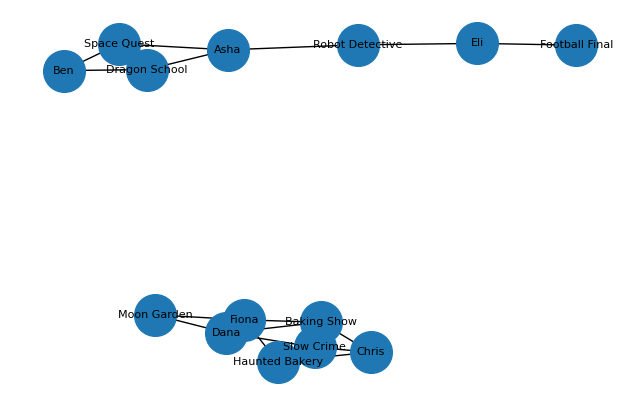

In [12]:
import matplotlib.pyplot as plt
import networkx as nx

pos = nx.spring_layout(graph, seed=42)
labels = {
    node: data.get("label", node)
    for node, data in graph.nodes(data=True)
}

plt.figure(figsize=(8, 5))
nx.draw_networkx(graph, pos=pos, labels=labels, node_size=900, font_size=8)
plt.axis("off")
plt.show()

## 4. Project to an item-item graph

Two items are connected when at least one user liked both. The edge weight counts how many users liked both items.

In [13]:
projection = item_projection(likes, items)
projection_edges(likes, items)

,item_a,title_a,item_b,title_b,shared_users
0,baking_show,Baking Show,haunted_bakery,Haunted Bakery,2
1,baking_show,Baking Show,moon_garden,Moon Garden,2
2,baking_show,Baking Show,slow_crime,Slow Crime,2
3,dragon_school,Dragon School,space_quest,Space Quest,2
4,dragon_school,Dragon School,robot_detective,Robot Detective,1
5,football_final,Football Final,robot_detective,Robot Detective,1
6,haunted_bakery,Haunted Bakery,moon_garden,Moon Garden,1
7,haunted_bakery,Haunted Bakery,slow_crime,Slow Crime,1
8,moon_garden,Moon Garden,slow_crime,Slow Crime,1
9,robot_detective,Robot Detective,space_quest,Space Quest,1


In [14]:
related_items_from_projection(likes, "Space Quest", items, top_n=5)

,item_id,title,shared_users,reason
0,dragon_school,Dragon School,2,2 user(s) liked both items
1,robot_detective,Robot Detective,1,1 user(s) liked both items


**Questions**

- Which item is most related to `Space Quest`?
- Is the edge weight strong evidence or weak evidence here?
- How would this change with thousands of users?

## 5. Recommend by shared neighbours

This is the Python version of the hand calculation from the worksheet. The score counts paths through items and users.

In [15]:
recommend_by_shared_neighbours(likes, items, user="Ben", top_n=5)

,item_id,title,score,raw_path_count,item_degree,reason
0,robot_detective,Robot Detective,2.0,2,3,1 shared user(s) with Space Quest; 1 shared us...


**Questions**

- Does this match your hand calculation?
- How is this different from the content-based method?
- Which method is easier to explain?

In [16]:
recommend_by_shared_neighbours(
    likes,
    items,
    user="Ben",
    top_n=5,
    penalise_popularity=True,
)

,item_id,title,score,raw_path_count,item_degree,reason
0,robot_detective,Robot Detective,0.666667,2,3,1 shared user(s) with Space Quest; 1 shared us...


**Question:** Did the popularity penalty help here, or did it just add noise?

## 6. Random-walk recommendations

A random walk samples paths instead of counting all of them exactly. The walk here is:

`user -> liked item -> another user -> another item`

In [17]:
random_walk_recommendations(
    likes,
    items,
    user="Asha",
    walks=1000,
    seed=42,
    top_n=5,
)

,item_id,title,visits,score,reason
0,football_final,Football Final,333,1.0,visited 333 time(s) in 333 successful walks


**Questions**

- Does the random-walk result agree with the shared-neighbour result?
- Change `walks` to 20, then 2000. What changes?
- Change the `seed`. What changes?
- Why might a random walk be useful on a very large graph?

## 7. Hide a known like and test it

We hide one known like, recommend without it, and check whether the recommender recovers it.

In [18]:
train_likes, hidden = hide_known_like(
    likes,
    user="Ben",
    item_id="dragon_school",
)

hidden

user                 Ben
item_id    dragon_school
rating                 5
Name: 4, dtype: object

In [19]:
test_recs = recommend_by_shared_neighbours(
    train_likes,
    items,
    user="Ben",
    top_n=5,
)

test_recs

,item_id,title,score,raw_path_count,item_degree,reason
0,dragon_school,Dragon School,1.0,1,2,1 shared user(s) with Space Quest
1,robot_detective,Robot Detective,1.0,1,3,1 shared user(s) with Space Quest


In [20]:
score_hidden_like(test_recs, hidden, k=5)

,item_id,rank,score,hit_at_5,note
0,dragon_school,1,1.0,True,lower rank is better


**Questions**

- Did the hidden item appear in the top 5?
- Is one hidden item enough to prove the recommender is good?
- What would a fairer test look like?

## 8. Design decisions

Write short answers.

- What should the system show a brand new user?
- Which method can recommend a new item before anyone likes it?
- Should the system downweight blockbusters?
- Should the top five recommendations all be very similar?
- Which recommendation from today would be easiest to explain?
- What changes if the platform optimises for watch time rather than satisfaction?

## Optional extensions

- Add a new item to `load_toy_items()` with tags but no ratings.
- Add yourself as a new user with three ratings.
- Change the like threshold from 4 to 3 in `load_toy_likes`.
- Hide a different known like.
- Write a product rule that combines graph score, content score, and one diversity rule.